<a href="https://colab.research.google.com/github/TejashwiniVadeghar/My-Projects/blob/main/AI_LAB_REC_AIML412.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#a. Breadth First Search

graph = {
'S': ['A','B','C'],
'A': ['D','E','B'],
'B': ['G'],
'C': ['F'],
'D': ['H'],
'E': ['G'],
'F': ['G'],
'G': [],
'H': []
}

closed = [] # List for visited nodes.
open = []     #Initialize a queue
child={}
def bfs(closed, graph, node): #function for BFS
  #closed.append(node)
  open.append(node)
  i=0
  while open:          # Creating loop to visit each node
    m = open.pop(0)
    closed.append(m)
    #print (m, end = " ")
    if(m=='G'):
      break
    i=0
    for neighbour in graph[m]:
        if neighbour not in closed:
          open.append(neighbour)
        if neighbour not in child.keys():
          child[neighbour]=m

# Driver Code
print("Following is the Breadth-First Search")
bfs(closed, graph, 'S')    # function calling
print("Open:",open)
print("Closed:",closed)
#print(child)
path=[]
goal="G"
path.append(goal)
while goal!="S":
  goal=child[goal]
  path.append(goal)
#path.append("S")
path.reverse()
print(path)

Following is the Breadth-First Search
Open: ['F', 'H', 'G', 'G']
Closed: ['S', 'A', 'B', 'C', 'D', 'E', 'B', 'G']
['S', 'B', 'G']


In [ ]:
# b. Depth First Search
graph = {
'S': ['A','B','C'],
'A': ['D','E','B'],
'B': ['G'],
'C': ['F'],
'D': ['H'],
'E': ['G'],
'F': ['G'],
'G': [],
'H': []
}

visited = set() # Set to keep track of visited nodes of graph.
open=[]
closed=[]
s=[]
def dfs(closed, graph, node):  #function for dfs
    open.append(node)
    while open:
      m = open.pop(0)
      closed.append(m)
      i=0
      s=[]

      for neighbour in graph[m]:
        if neighbour not in open:
          s.append(neighbour)
      open[:0]=s
      #for x in s:
       #   open.append(x)
      print(open)
      if(m=="G"):
        break

# Driver Code
print("Following is the Depth-First Search")
dfs(closed, graph, 'S')
print(closed)

Following is the Depth-First Search
['A', 'B', 'C']
['D', 'E', 'B', 'C']
['H', 'E', 'B', 'C']
['E', 'B', 'C']
['G', 'B', 'C']
['B', 'C']
['S', 'A', 'D', 'H', 'E', 'G']


In [ ]:
#c. Depth First Iterative Deepening Search

graph = {
'S': ['A','B','C'],
'A': ['D','E','B'],
'B': ['G'],
'C': ['F'],
'D': ['H'],
'E': ['G'],
'F': ['G'],
'G': [],
'H': []
}
def IDDFS(node,maxDepth,goal) :
        for depth in range(0,maxDepth):
            print("\n","Depth = " , depth , ", DLS Traversal => ")

            if (DLS(node, goal, depth)):
                return True
        return False

    # Depth limited search method
def DLS(node,goal,depth) :
        print(node)

        if (node == goal) :
            return True;


        if (depth == 0) :
            return False


        for neighbour in graph[node] :
            if (DLS(neighbour, goal, depth - 1)) :
                return True


        return False
s=IDDFS("S", 3, "G")


 Depth =  0 , DLS Traversal => 
S

 Depth =  1 , DLS Traversal => 
S
A
B
C

 Depth =  2 , DLS Traversal => 
S
A
D
E
B
B
G


In [ ]:
#A* program

def heuristic(state, goal_state):
    distance = 0
    for i in range(len(state)):
        if state[i] != goal_state[i]:
            distance += 1
    return distance

def a_star_search(graph, start_state, goal_state):
    open_list = [(start_state, 0)]
    closed_list = set()
    g_scores = {start_state: 0}
    f_scores = {start_state: heuristic(start_state, goal_state)}

    while open_list:
        current_state, _ = min(open_list, key=lambda x: f_scores[x[0]])
        open_list.remove((current_state, _))

        if current_state == goal_state:
            path = []
            while current_state != start_state:
                path.append(current_state)
                current_state = graph[current_state][1]
            path.append(start_state)
            path.reverse()
            return " -> ".join(path)

        closed_list.add(current_state)

        for neighbor in graph[current_state][0]:
            g_score = g_scores[current_state] + 1
            f_score = g_score + heuristic(neighbor, goal_state)

            if neighbor in closed_list and g_score >= g_scores[neighbor]:
                continue

            if neighbor not in [state for state, _ in open_list] or g_score < g_scores[neighbor]:
                g_scores[neighbor] = g_score
                f_scores[neighbor] = f_score
                graph[neighbor] = (graph[neighbor][0], current_state)
                if neighbor not in [state for state, _ in open_list]:
                       open_list.append((neighbor, f_score))

    return None

# Example graph representation
G = {
    'S': (['A', 'B', 'C'], None),
    'A': (['D', 'E', 'B'], None),
    'B': (['G'], None),
    'C': (['F'], None),
    'D': (['H'], None),
    'E': (['G'], None),
    'F': (['G'], None),
    'H': ([], None),
    'G': ([], None)  # Add 'G' with an empty list as its value
}

start_state = 'S'
goal_state = 'G'

path = a_star_search(G, start_state, goal_state)
print(path)

S -> B -> G


In [ ]:
def is_valid(board, row, col):
    # Check if placing a queen at (row, col) violates any constraints
    for i in range(col):
        if board[row][i] == 1:
            return False
    for i, j in zip(range(row, -1, -1), range(col, -1, -1)):
        if board[i][j] == 1:
            return False
    for i, j in zip(range(row, len(board), 1), range(col, -1, -1)):
        if board[i][j] == 1:
            return False
    return True

def solve_n_queens(board, col):
    # Base case: All queens are placed
    if col >= len(board):
        return True

    for i in range(len(board)):
        if is_valid(board, i, col):
            board[i][col] = 1
            if solve_n_queens(board, col + 1):
                return True
            board[i][col] = 0

    return False

def print_board(board):
    for row in board:
        print(' '.join(str(cell) for cell in row))

def solve_eight_queens():
    board = [[0] * 8 for _ in range(8)]
    if solve_n_queens(board, 0):
        print_board(board)
    else:
        print("No solution exists.")

solve_eight_queens()

1 0 0 0 0 0 0 0
0 0 0 0 0 0 1 0
0 0 0 0 1 0 0 0
0 0 0 0 0 0 0 1
0 1 0 0 0 0 0 0
0 0 0 1 0 0 0 0
0 0 0 0 0 1 0 0
0 0 1 0 0 0 0 0


In [ ]:
import math

def minimax (curDepth, nodeIndex,
             maxTurn, scores,
             targetDepth):

    # base case : targetDepth reached
    if (curDepth == targetDepth):
        return scores[nodeIndex]

    if (maxTurn):
        return max(minimax(curDepth + 1, nodeIndex * 2,
                    False, scores, targetDepth),
                   minimax(curDepth + 1, nodeIndex * 2 + 1,
                    False, scores, targetDepth))

    else:
        return min(minimax(curDepth + 1, nodeIndex * 2,
                     True, scores, targetDepth),
                   minimax(curDepth + 1, nodeIndex * 2 + 1,
                     True, scores, targetDepth))

# Driver code
scores = [3, 5, 2, 9, 12, 5, 23, 23]

treeDepth = math.log(len(scores), 2)

print("The optimal value is : ", end = "")
print(minimax(0, 0, True, scores, treeDepth))

The optimal value is : 12


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Naive Bayes On The Iris Dataset
from csv import reader
from random import seed
from random import randrange
from math import sqrt
from math import exp
from math import pi

# Load a CSV file
def load_csv(filename):
	dataset = list()
	with open(filename, 'r') as file:
		csv_reader = reader(file)
		for row in csv_reader:
			if not row:
				continue
			dataset.append(row)
	return dataset

# Convert string column to float
def str_column_to_float(dataset, column):
	for row in dataset:
		row[column] = float(row[column].strip())

# Convert string column to integer
def str_column_to_int(dataset, column):
	class_values = [row[column] for row in dataset]
	unique = set(class_values)
	lookup = dict()
	for i, value in enumerate(unique):
		lookup[value] = i
	for row in dataset:
		row[column] = lookup[row[column]]
	return lookup

# Split a dataset into k folds
def cross_validation_split(dataset, n_folds):
	dataset_split = list()
	dataset_copy = list(dataset)
	fold_size = int(len(dataset) / n_folds)
	for _ in range(n_folds):
		fold = list()
		while len(fold) < fold_size:
			index = randrange(len(dataset_copy))
			fold.append(dataset_copy.pop(index))
		dataset_split.append(fold)
	return dataset_split

# Calculate accuracy percentage
def accuracy_metric(actual, predicted):
	correct = 0
	for i in range(len(actual)):
		if actual[i] == predicted[i]:
			correct += 1
	return correct / float(len(actual)) * 100.0

# Evaluate an algorithm using a cross validation split
def evaluate_algorithm(dataset, algorithm, n_folds, *args):
	folds = cross_validation_split(dataset, n_folds)
	scores = list()
	for fold in folds:
		train_set = list(folds)
		train_set.remove(fold)
		train_set = sum(train_set, [])
		test_set = list()
		for row in fold:
			row_copy = list(row)
			test_set.append(row_copy)
			row_copy[-1] = None
		predicted = algorithm(train_set, test_set, *args)
		actual = [row[-1] for row in fold]
		accuracy = accuracy_metric(actual, predicted)
		scores.append(accuracy)
	return scores

# Split the dataset by class values, returns a dictionary
def separate_by_class(dataset):
	separated = dict()
	for i in range(len(dataset)):
		vector = dataset[i]
		class_value = vector[-1]
		if (class_value not in separated):
			separated[class_value] = list()
		separated[class_value].append(vector)
	return separated

# Calculate the mean of a list of numbers
def mean(numbers):
	return sum(numbers)/float(len(numbers))

# Calculate the standard deviation of a list of numbers
def stdev(numbers):
	avg = mean(numbers)
	variance = sum([(x-avg)**2 for x in numbers]) / float(len(numbers)-1)
	return sqrt(variance)

# Calculate the mean, stdev and count for each column in a dataset
def summarize_dataset(dataset):
	summaries = [(mean(column), stdev(column), len(column)) for column in zip(*dataset)]
	del(summaries[-1])
	return summaries

# Split dataset by class then calculate statistics for each row
def summarize_by_class(dataset):
	separated = separate_by_class(dataset)
	summaries = dict()
	for class_value, rows in separated.items():
		summaries[class_value] = summarize_dataset(rows)
	return summaries

# Calculate the Gaussian probability distribution function for x
def calculate_probability(x, mean, stdev):
	exponent = exp(-((x-mean)*2 / (2 * stdev*2 )))
	return (1 / (sqrt(2 * pi) * stdev)) * exponent

# Calculate the probabilities of predicting each class for a given row
def calculate_class_probabilities(summaries, row):
	total_rows = sum([summaries[label][0][2] for label in summaries])
	probabilities = dict()
	for class_value, class_summaries in summaries.items():
		probabilities[class_value] = summaries[class_value][0][2]/float(total_rows)
		for i in range(len(class_summaries)):
			mean, stdev, _ = class_summaries[i]
			probabilities[class_value] *= calculate_probability(row[i], mean, stdev)
	return probabilities

# Predict the class for a given row
def predict(summaries, row):
	probabilities = calculate_class_probabilities(summaries, row)
	best_label, best_prob = None, -1
	for class_value, probability in probabilities.items():
		if best_label is None or probability > best_prob:
			best_prob = probability
			best_label = class_value
	return best_label

# Naive Bayes Algorithm
def naive_bayes(train, test):
	summarize = summarize_by_class(train)
	predictions = list()
	for row in test:
		output = predict(summarize, row)
		predictions.append(output)
	return(predictions)

# Test Naive Bayes on Iris Dataset
seed(1)
filename = '/content/drive/MyDrive/iris.csv'
dataset = load_csv(filename)
for i in range(len(dataset[0])-1):
	str_column_to_float(dataset, i)
# convert class column to integers
str_column_to_int(dataset, len(dataset[0])-1)
# evaluate algorithm
n_folds = 5
scores = evaluate_algorithm(dataset, naive_bayes, n_folds)
print('Scores: %s' % scores)
print('Mean Accuracy: %.3f%%' % (sum(scores)/float(len(scores))))

TypeError: ignored

Cross-validation scores: [0.96666667 0.96666667 0.9        1.         1.        ]
Mean accuracy: 0.9666666666666668


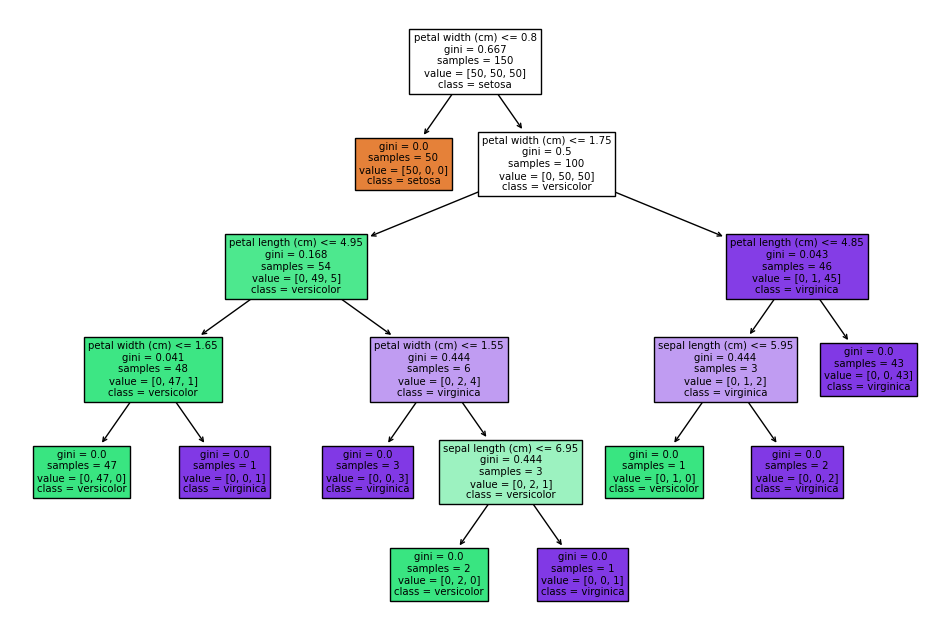

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DecisionTreeClassifier
clf = DecisionTreeClassifier()

# Perform cross-validation
scores = cross_val_score(clf, X, y, cv=5)  # 5-fold cross-validation

# Print the cross-validation scores
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())


# Fit the model on the entire dataset
clf.fit(X, y)

# Visualize the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

[(4, 21), (5, 19), (10, 24), (4, 17), (3, 16), (11, 25), (14, 24), (6, 22), (10, 21), (12, 21)]


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

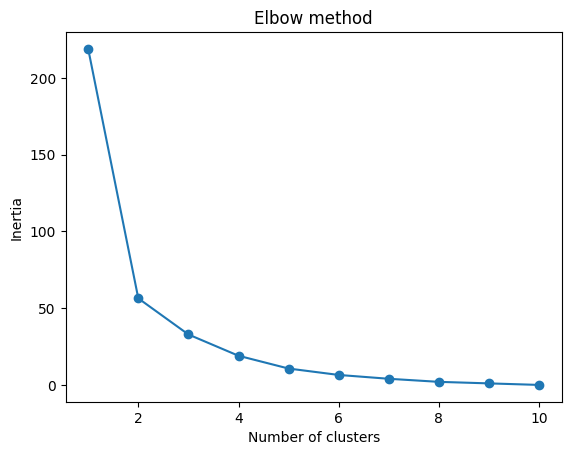

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


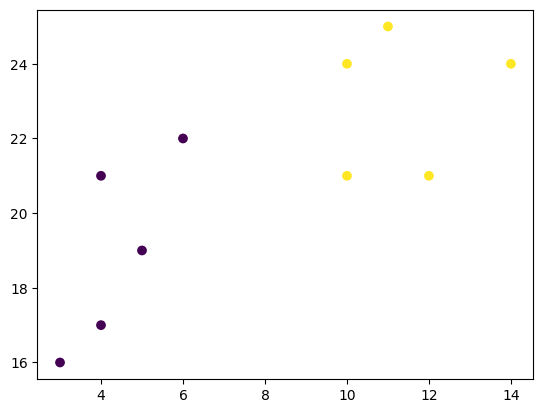

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
data = list(zip(x, y))
print(data)
inertias = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)
plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)
plt.scatter(x, y, c=kmeans.labels_)
plt.show()

In [ ]:
!pip install nltk

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import re

Text = " Artificial Intelligence is a new technology in the field of computer science. “Artificial” means man-made that is not natural and “Intelligence” refers to the ability to think and make decisions."
w=0
s=0
print("The text is \n",Text)

print("\nSegmenting the above text into sentences\n")
sentence_endings = r"[.?!]"
sentences=re.split(sentence_endings, Text)
for sentence in sentences:
    s=s+1
    print(sentence)

print("Segmenting the above text into words ")
PATTERN = r"\w+"
words=re.findall(PATTERN, Text)
for word in words:
    w=w+1
    print(word)


print("No of sentences=",s)
print("No of words=",w)


The text is 
  Artificial Intelligence is a new technology in the field of computer science. “Artificial” means man-made that is not natural and “Intelligence” refers to the ability to think and make decisions.

Segmenting the above text into sentences

 Artificial Intelligence is a new technology in the field of computer science
 “Artificial” means man-made that is not natural and “Intelligence” refers to the ability to think and make decisions

Segmenting the above text into words 
Artificial
Intelligence
is
a
new
technology
in
the
field
of
computer
science
Artificial
means
man
made
that
is
not
natural
and
Intelligence
refers
to
the
ability
to
think
and
make
decisions
No of sentences= 3
No of words= 31


In [ ]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

#Dummy text
txt =	"Vijay and Raju were friends."\
	"On a holiday they went walking into a forest, enjoying the beauty of nature" \
	"Suddenly they saw a bear coming at them. " \
	"Raju, who knew all about climbing trees, ran up to a tree and climbed up quickly." \
	"He didn’t think of Vijay. Vijay had no idea how to climb the tree." \
	"Vijay thought for a second. "\
	"He’d heard animals don’t prefer dead bodies, so he fell to the ground and held his breath."\
        " The bear sniffed him and thought he was dead. So, it went on its way" \

print("the text is \n",txt)
# sent_tokenize is one of instances of PunktSentenceTokenizer from the nltk.tokenize.punkt module

tokenized = sent_tokenize(txt)
for i in tokenized:

	# Word tokenizers is used to find the words and punctuation in a string
	wordsList = nltk.word_tokenize(i)

    	# Using a Tagger. Which is part-of-speech tagger or POS-tagger.
	tagged = nltk.pos_tag(wordsList)

	print("\n",tagged)


the text is 
 Vijay and Raju were friends.On a holiday they went walking into a forest, enjoying the beauty of natureSuddenly they saw a bear coming at them. Raju, who knew all about climbing trees, ran up to a tree and climbed up quickly.He didn’t think of Vijay. Vijay had no idea how to climb the tree.Vijay thought for a second. He’d heard animals don’t prefer dead bodies, so he fell to the ground and held his breath. The bear sniffed him and thought he was dead. So, it went on its way

 [('Vijay', 'NNP'), ('and', 'CC'), ('Raju', 'NNP'), ('were', 'VBD'), ('friends.On', 'VB'), ('a', 'DT'), ('holiday', 'NN'), ('they', 'PRP'), ('went', 'VBD'), ('walking', 'VBG'), ('into', 'IN'), ('a', 'DT'), ('forest', 'NN'), (',', ','), ('enjoying', 'VBG'), ('the', 'DT'), ('beauty', 'NN'), ('of', 'IN'), ('natureSuddenly', 'RB'), ('they', 'PRP'), ('saw', 'VBD'), ('a', 'DT'), ('bear', 'JJ'), ('coming', 'VBG'), ('at', 'IN'), ('them', 'PRP'), ('.', '.')]

 [('Raju', 'NNP'), (',', ','), ('who', 'WP'), ('kne

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True